## For each allele and fold metrics have been computed:
(PCC, MSE, AUC) and stored in results_non_nested/all_alleles_cv_results.csv

## In this notebook:
1) Metrics are loaded
2) folds and alleles are summarised
3) prepare plots to compare non-nested versus nested CV later


## Imports

In [9]:
import os
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
from sklearn.metrics import roc_auc_score, roc_curve, mean_squared_error
import matplotlib.pyplot as plt
import sys
!{sys.executable} -m pip install seaborn

In [11]:
import seaborn as sns

## Helper function

In [2]:
def evaluate_prediction_csv(csv_path, binder_threshold=0.426):
    df = pd.read_csv(csv_path)

    required_cols = {"target", "prediction"}
    if not required_cols.issubset(df.columns):
        raise ValueError(f"{csv_path} must contain columns: {required_cols}")

    if df.empty:
        raise ValueError(f"{csv_path} is empty")

    y_true = df["target"].values
    y_pred = df["prediction"].values

    if len(y_true) < 2:
        pcc = np.nan
    elif np.std(y_true) == 0 or np.std(y_pred) == 0:
        pcc = np.nan
    else:
        pcc, _ = pearsonr(y_true, y_pred)

    mse = mean_squared_error(y_true, y_pred)

    y_bin = (y_true >= binder_threshold).astype(int)

    if len(np.unique(y_bin)) < 2:
        auc = np.nan
        fpr, tpr = None, None
    else:
        auc = roc_auc_score(y_bin, y_pred)
        fpr, tpr, _ = roc_curve(y_bin, y_pred)

    return {
        "df": df,
        "n_peptides": len(df),
        "n_binders": int(y_bin.sum()),
        "pcc": pcc,
        "mse": mse,
        "auc": auc,
        "fpr": fpr,
        "tpr": tpr,
        "binder_threshold": binder_threshold,
    }

## Sanity check single allele

from predictions.csv

In [3]:
allele = "A0201"
fold = "fold_000"
csv_path = f"results_non_nested/{allele}/{fold}/predictions.csv"

result = evaluate_prediction_csv(csv_path, binder_threshold=0.426)

print("PCC:", result["pcc"])
print("MSE:", result["mse"])
print("AUC:", result["auc"])
print("N peptides:", result["n_peptides"])
print("N binders:", result["n_binders"])

PCC: 0.6051770840822633
MSE: 0.0684970052708864
AUC: 0.8278445606206919
N peptides: 2471
N binders: 944


Plot the ROC curve

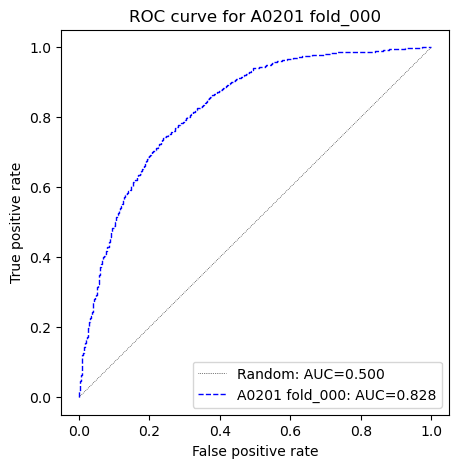

In [4]:
plt.figure(figsize=(5, 5))
plt.plot([0, 1], [0, 1], "k:", lw=0.5, label="Random: AUC=0.500")

if result["fpr"] is not None:
    plt.plot(result["fpr"], result["tpr"], "b--", lw=1,
             label=f"{allele} {fold}: AUC={result['auc']:.3f}")

plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title(f"ROC curve for {allele} {fold}")
plt.legend()
plt.show()

## Load fold-level non-nested CV metrics

In [5]:
non_nested_path = "results_non_nested/all_alleles_cv_results.csv"

metrics_df = pd.read_csv(non_nested_path)

metrics_df.head()

,allele,fold,cv_type,n_peptides,n_binders,pcc,mse,auc,binder_threshold
0,A0101,fold_000,non_nested,925,82,0.058830,0.048305,0.608208,0.426
1,A0101,fold_001,non_nested,925,82,0.070887,0.045397,0.605228,0.426
2,A0101,fold_002,non_nested,926,82,0.089165,0.043692,0.588501,0.426
3,A0101,fold_003,non_nested,926,83,0.132524,0.044431,0.625334,0.426
4,A0101,fold_004,non_nested,926,83,0.110391,0.047485,0.625134,0.426


In [6]:
print("Shape:", metrics_df.shape)
print("Columns:", metrics_df.columns.tolist())
print("Alleles:", sorted(metrics_df["allele"].unique()))
print("Folds:", sorted(metrics_df["fold"].unique()))
print("CV types:", metrics_df["cv_type"].unique())

Shape: (125, 9)
Columns: ['allele', 'fold', 'cv_type', 'n_peptides', 'n_binders', 'pcc', 'mse', 'auc', 'binder_threshold']
Alleles: ['A0101', 'A0201', 'A0202', 'A0203', 'A0206', 'A0301', 'A1101', 'A2301', 'A2402', 'A2403', 'A2601', 'A2902', 'A3001', 'A3002', 'A3101', 'A3301', 'A6801', 'A6802', 'A6901', 'B0702', 'B0801', 'B1501', 'B1801', 'B2705', 'B3501']
Folds: ['fold_000', 'fold_001', 'fold_002', 'fold_003', 'fold_004']
CV types: ['non_nested']


## Collapse fold-level metrics to allele-level summary

In [ ]:
allele_summary_df = ( #one row per allele after aggregating fold metrics
    metrics_df # fold-level non nested
    .groupby("allele", as_index=False)
    .agg(
        mean_pcc=("pcc", "mean"),
        std_pcc=("pcc", "std"),
        mean_mse=("mse", "mean"),
        std_mse=("mse", "std"),
        mean_auc=("auc", "mean"),
        std_auc=("auc", "std"),
        mean_n_peptides=("n_peptides", "mean"),
        mean_n_binders=("n_binders", "mean"),
        n_folds=("fold", "nunique"),
    )
)

allele_summary_df.head()

,allele,mean_pcc,std_pcc,mean_mse,std_mse,mean_auc,std_auc,mean_n_peptides,mean_n_binders,n_folds
0,A0101,0.092360,0.029723,0.045862,0.001974,0.610481,0.015421,925.6,82.4,5
1,A0201,0.600456,0.015903,0.069868,0.002156,0.823533,0.008639,2471.2,944.8,5
2,A0202,0.424451,0.023801,0.091028,0.003532,0.718069,0.011489,1157.6,519.2,5
3,A0203,0.463247,0.055300,0.088480,0.007807,0.727826,0.027873,1154.4,511.2,5
4,A0206,0.433034,0.035936,0.084837,0.007534,0.721475,0.024904,1149.6,410.4,5


## Summarise metrics across folds for each allele

basic per-allele performance (non-nested only)

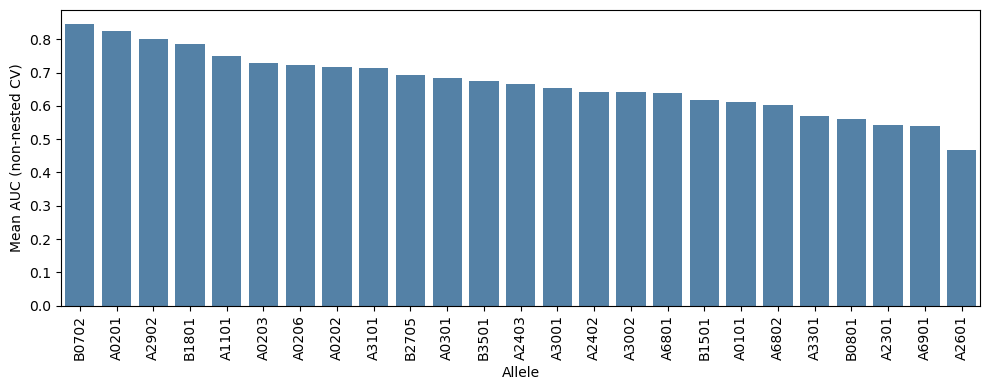

In [12]:
# Mean AUC per allele

plt.figure(figsize=(10, 4))
sns.barplot(
    data=allele_summary_df.sort_values("mean_auc", ascending=False),
    x="allele", y="mean_auc", color="steelblue"
)
plt.xticks(rotation=90)
plt.ylabel("Mean AUC (non-nested CV)")
plt.xlabel("Allele")
plt.tight_layout()
plt.show()

In [15]:
print(metrics_df.shape)
print(metrics_df.columns.tolist())
print(metrics_df["allele"].nunique(), "alleles")
print(metrics_df["fold"].unique())

(125, 9)
['allele', 'fold', 'cv_type', 'n_peptides', 'n_binders', 'pcc', 'mse', 'auc', 'binder_threshold']
25 alleles
['fold_000' 'fold_001' 'fold_002' 'fold_003' 'fold_004']


In [17]:
allele_summary_df.sort_values("mean_auc", ascending=True).head()

,allele,mean_pcc,std_pcc,mean_mse,std_mse,mean_auc,std_auc,mean_n_peptides,mean_n_binders,n_folds
10,A2601,-0.063497,0.018728,0.050427,0.005604,0.467763,0.029978,537.6,42.4,5
18,A6901,0.062814,0.046612,0.053269,0.003023,0.538952,0.023815,666.4,68.8,5
7,A2301,0.165845,0.121879,0.143725,0.028595,0.543406,0.069790,83.2,39.2,5
20,B0801,0.024379,0.021246,0.025439,0.004597,0.561121,0.056656,566.4,16.0,5
15,A3301,0.111646,0.029903,0.083459,0.002537,0.570378,0.033296,912.0,147.2,5


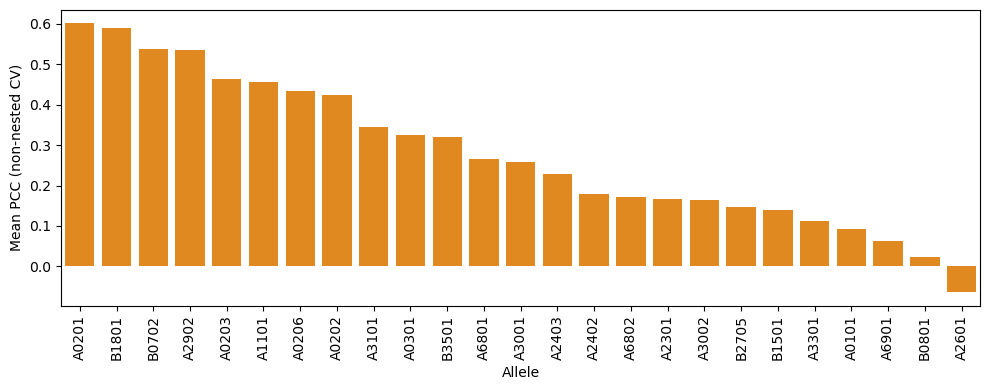

In [13]:
# Mean PCC per allele

plt.figure(figsize=(10, 4))
sns.barplot(
    data=allele_summary_df.sort_values("mean_pcc", ascending=False),
    x="allele", y="mean_pcc", color="darkorange"
)
plt.xticks(rotation=90)
plt.ylabel("Mean PCC (non-nested CV)")
plt.xlabel("Allele")
plt.tight_layout()
plt.show()

## Tentative plots

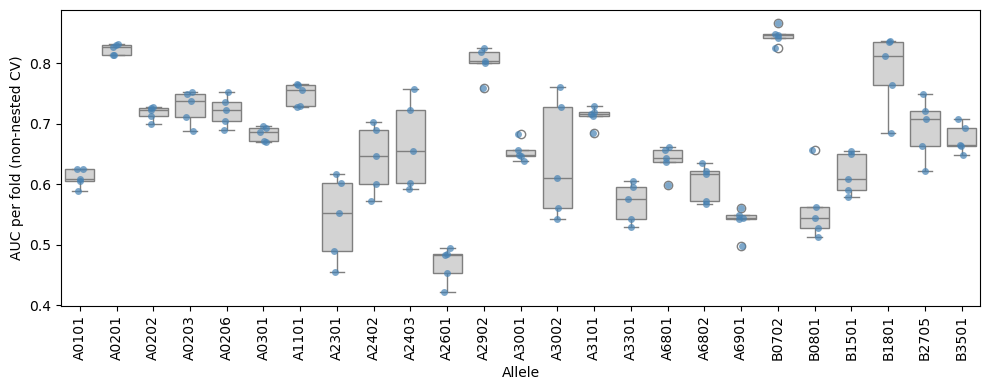

In [14]:
# Plot of AUC by allele to demonstrate variability across folds

plt.figure(figsize=(10, 4))
sns.boxplot(
    data=metrics_df,
    x="allele", y="auc", color="lightgray"
)
sns.stripplot(
    data=metrics_df,
    x="allele", y="auc", color="steelblue", alpha=0.7
)
plt.xticks(rotation=90)
plt.ylabel("AUC per fold (non-nested CV)")
plt.xlabel("Allele")
plt.tight_layout()
plt.show()

## Compare non-nested and nested CV

PCC versus number of binders

x-axis = mean number of binders per allele

y-axis = mean PCC per allele

color = cv_type

maybe label = allele